In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange
from bez.cnn.model import SketchDenoiser
from bez.data import load_normalized
import torch
from meta import ROOT_DIR
from torchvision.transforms import v2
import random
from pathlib import Path
import marimo as mo
import polars as pl
import base64
from io import BytesIO

# Load generated images

See svg_dataset.py for information about how we generated the images

In [ ]:
N_IMAGES = 3000
D_IMAGE = 256


class SVGDataset:
    def __init__(self, path: Path, std_noise=0.1):
        self.std_noise = std_noise
        self.x_images = [
            load_normalized(path / f"x_{i}.png", only_alpha=True, d=256)
            for i in range(N_IMAGES)
        ]
        self.y_images = [
            load_normalized(path / f"y_{i}.png", only_alpha=True, d=256)
            for i in range(N_IMAGES)
        ]

    def __len__(self):
        return N_IMAGES

    def __getitem__(self, idx):
        x = self.x_images[idx]
        y = self.y_images[idx]
        noise = self.std_noise * torch.randn((1, D_IMAGE, D_IMAGE))
        return (
            torch.tensor(x, dtype=torch.float32).unsqueeze(0) + noise,
            # very important for numerical stability (BCE loss)
            0.99 * torch.tensor(y, dtype=torch.float32).unsqueeze(0),
        )

In [ ]:
dataset = SVGDataset(ROOT_DIR / "data" / "train", std_noise=0.05)

In [ ]:
def figure(data, w=D_IMAGE, h=D_IMAGE, cmap="binary"):
    fig = plt.figure()
    ax = fig.gca()
    ax.imshow(data.reshape(h, w), cmap=cmap)
    ax.axis(False)
    import base64


    # Save plot to a BytesIO object
    buffer = BytesIO()
    fig.savefig(buffer, format='png')
    buffer.seek(0)

    # Encode the image in base64
    image_base64 = base64.b64encode(buffer.getvalue()).decode()

    # HTML embedding
    html_string = f'<img src="data:image/png;base64,{image_base64}" />'
    return mo.Html(html_string)

In [ ]:
def table(data):
    df = pl.DataFrame(data)
    # Build the table HTML
    html_parts = ['<table>']

    # Add table header with centered text
    html_parts.append('<thead>')
    html_parts.append('<tr>')
    for col in df.columns:
        html_parts.append(f'<th style="text-align: center;">{col}</th>')
    html_parts.append('</tr>')
    html_parts.append('</thead>')

    # Add table body
    html_parts.append('<tbody>')
    for row in df.iter_rows(named=False):
        html_parts.append('<tr>')
        for cell_value in row:
            html_parts.append(f'<td>{cell_value}</td>')
        html_parts.append('</tr>')
    html_parts.append('</tbody>')

    html_parts.append('</table>')

    return mo.Html(''.join(html_parts))

Input,Ground Truth
,

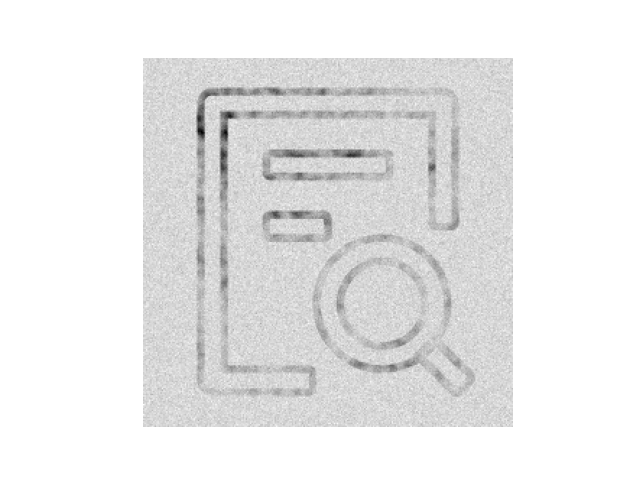
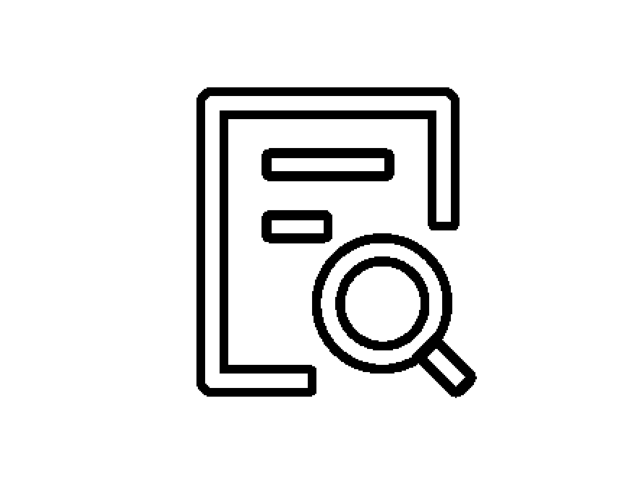

In [ ]:
_x, _y = dataset[0]
table([{"Input": figure(_x).text, "Ground Truth": figure(_y).text}])

In [ ]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=50, shuffle=True)

# Model training

This model is a 7-layer CNN

Each convolution kernel is of size 3x3 with 32 channels.

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
N_EPOCH = 30
model = SketchDenoiser(32).to(device)
criterion = torch.nn.BCELoss()
opti = torch.optim.AdamW(model.parameters(), lr=0.005)
losses = []
for epoch in range(N_EPOCH):
    epoch_loss = 0
    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        opti.zero_grad()
        y_pred = model.forward(batch_x)
        loss = criterion(y_pred, batch_y)
        loss.backward()
        opti.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{N_EPOCH}, Loss: {avg_loss:.4f}")
torch.save(model.state_dict(), "model.pt2")

Epoch 1/30, Loss: 0.1285
Epoch 2/30, Loss: 0.0538
Epoch 3/30, Loss: 0.0440
Epoch 4/30, Loss: 0.0392
Epoch 5/30, Loss: 0.0365
Epoch 6/30, Loss: 0.0348
Epoch 7/30, Loss: 0.0327
Epoch 8/30, Loss: 0.0314
Epoch 9/30, Loss: 0.0302
Epoch 10/30, Loss: 0.0290
Epoch 11/30, Loss: 0.0281
Epoch 12/30, Loss: 0.0275
Epoch 13/30, Loss: 0.0266
Epoch 14/30, Loss: 0.0265
Epoch 15/30, Loss: 0.0259
Epoch 16/30, Loss: 0.0258
Epoch 17/30, Loss: 0.0251
Epoch 18/30, Loss: 0.0247
Epoch 19/30, Loss: 0.0246
Epoch 20/30, Loss: 0.0245
Epoch 21/30, Loss: 0.0240
Epoch 22/30, Loss: 0.0239
Epoch 23/30, Loss: 0.0237
Epoch 24/30, Loss: 0.0233
Epoch 25/30, Loss: 0.0234
Epoch 26/30, Loss: 0.0232
Epoch 27/30, Loss: 0.0227
Epoch 28/30, Loss: 0.0229
Epoch 29/30, Loss: 0.0225
Epoch 30/30, Loss: 0.0224


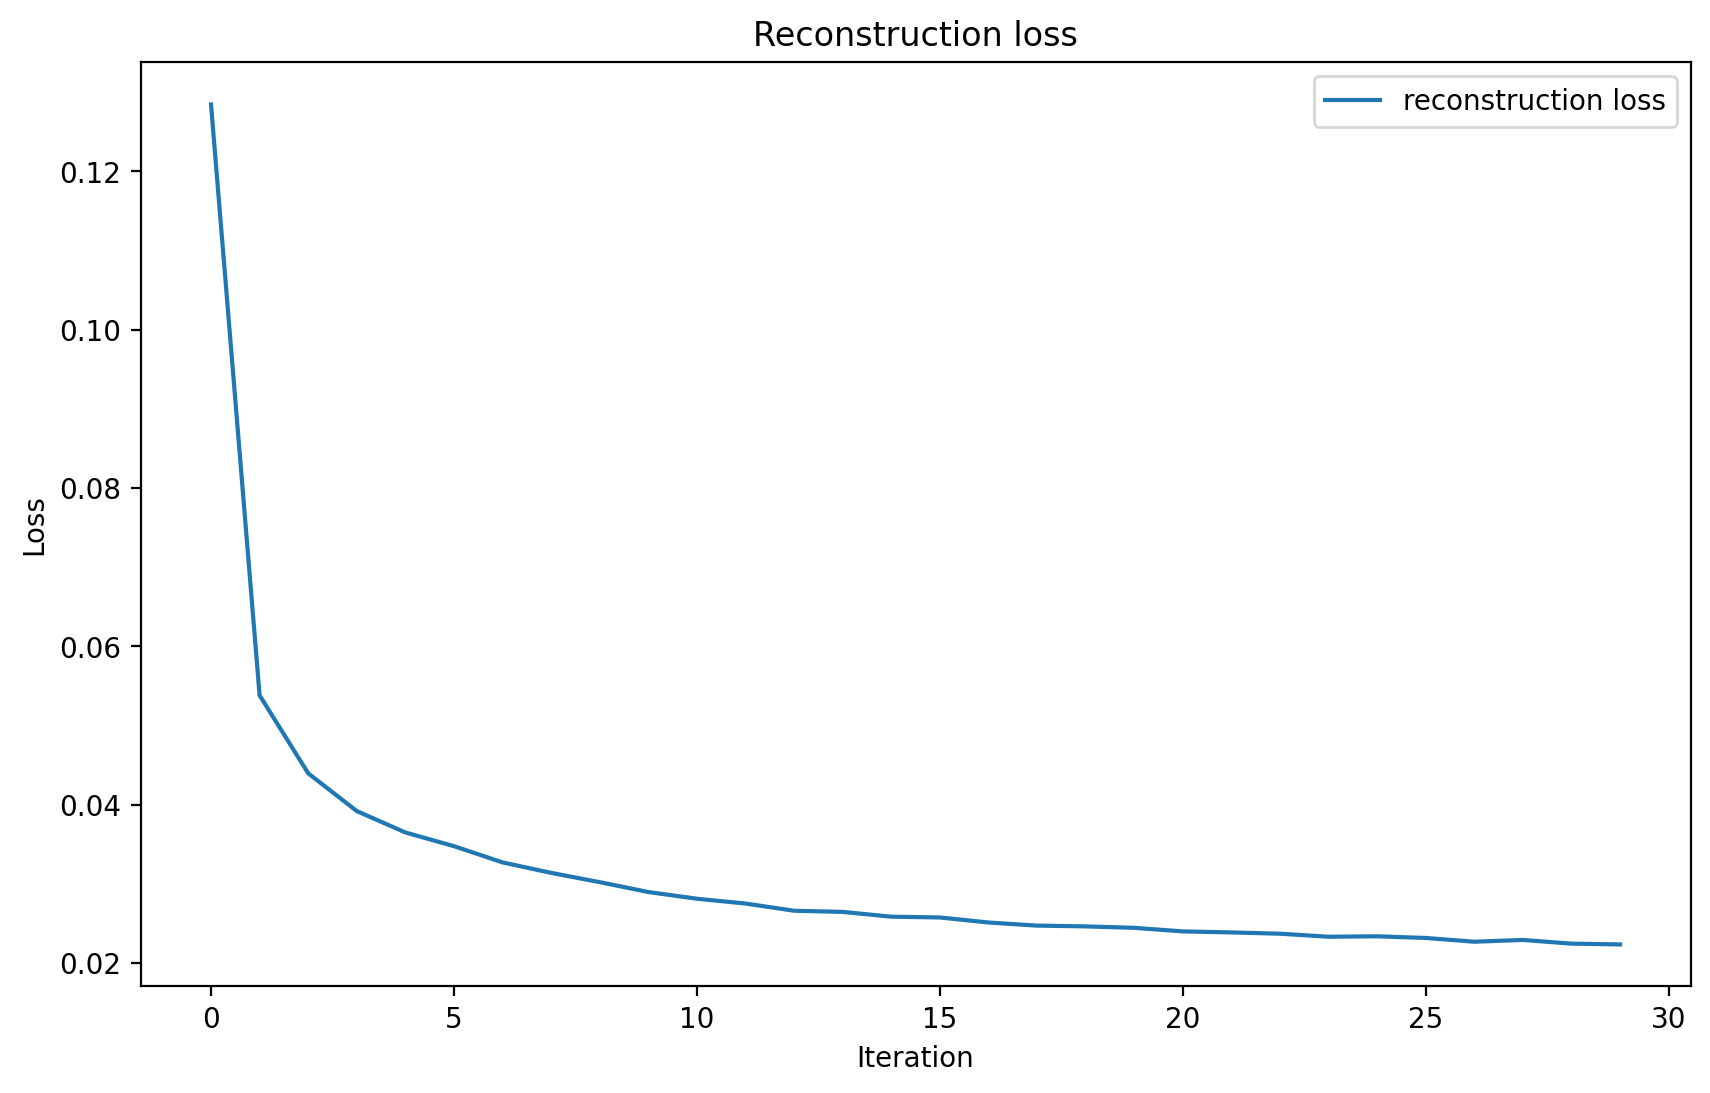

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(losses)), losses, label="reconstruction loss")
plt.title("Reconstruction loss")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.gca()

In [ ]:
# we convert
model.eval()
model_cpu = model.cpu()

# Visualisation of model outputs

Input,Predicted,Ground truth
,,
,,
,,
,,
,,
,,

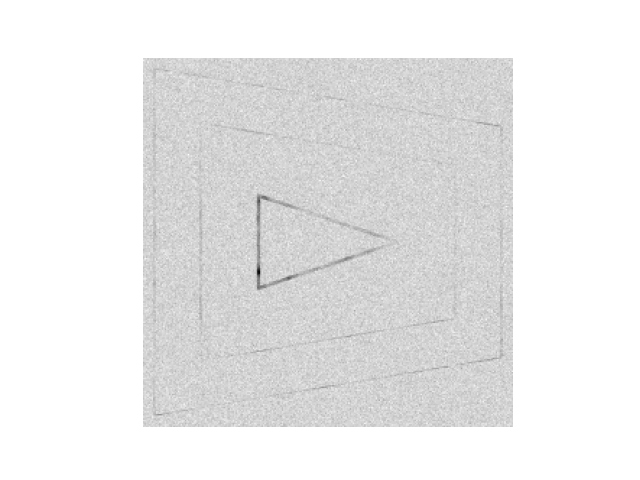
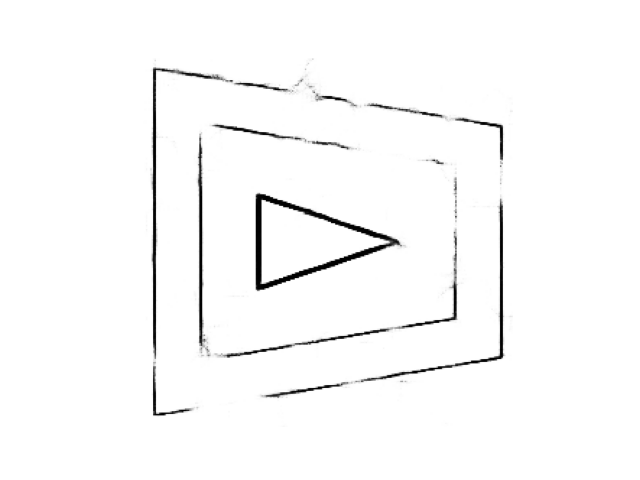
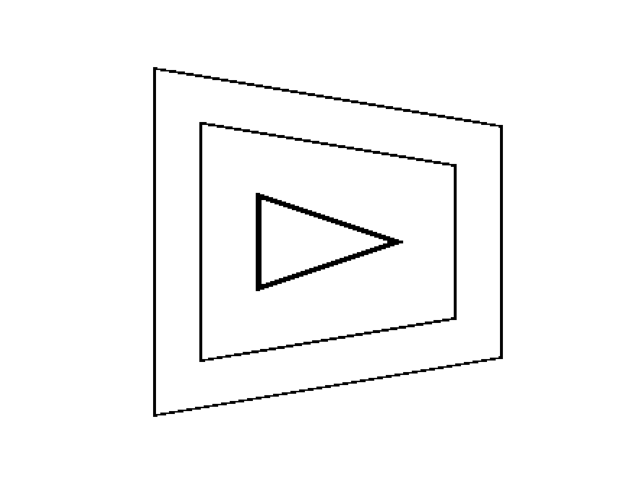
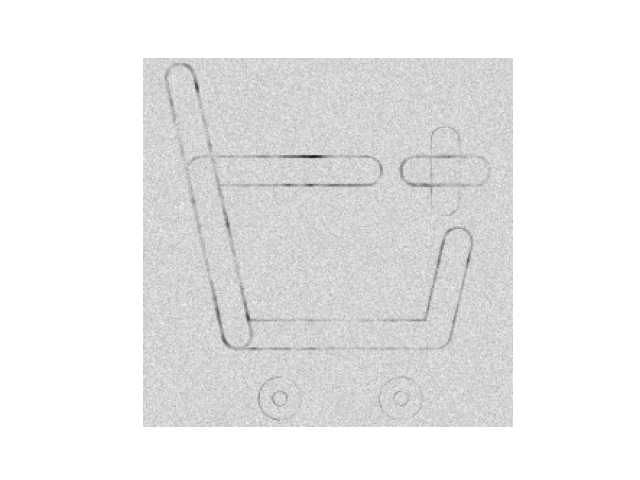
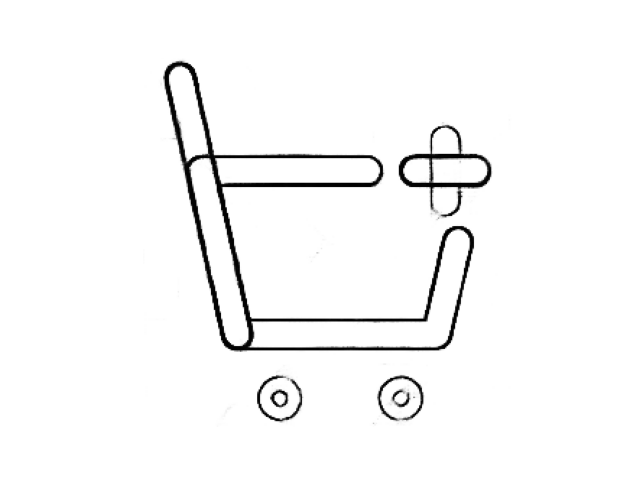
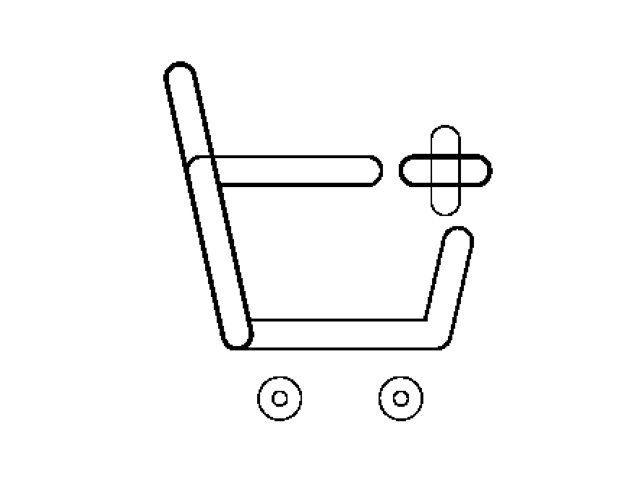
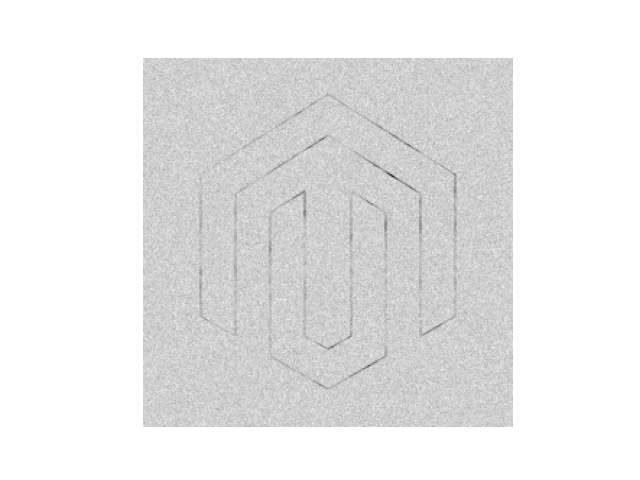
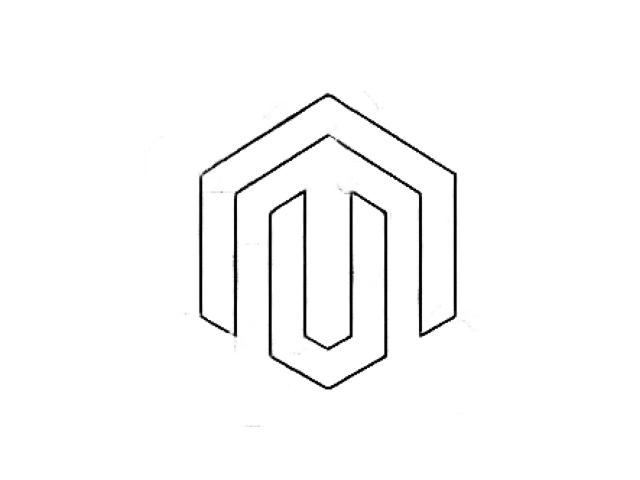
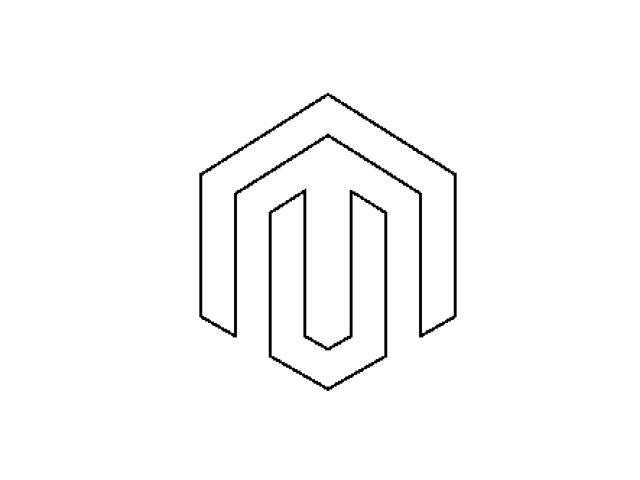
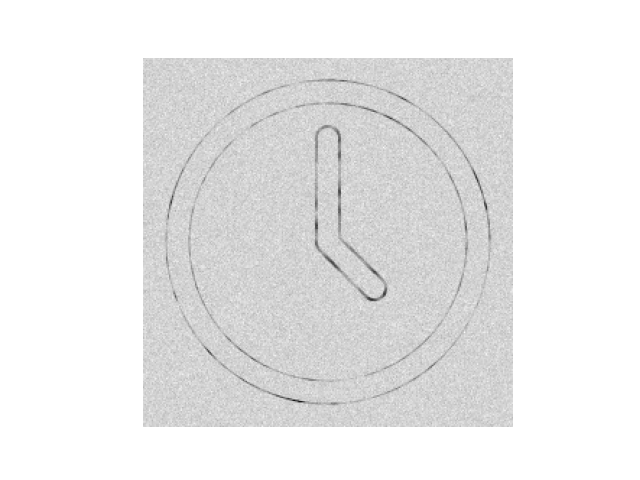
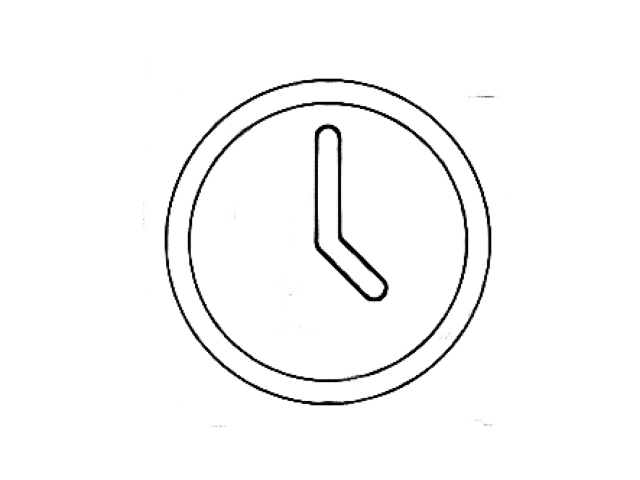
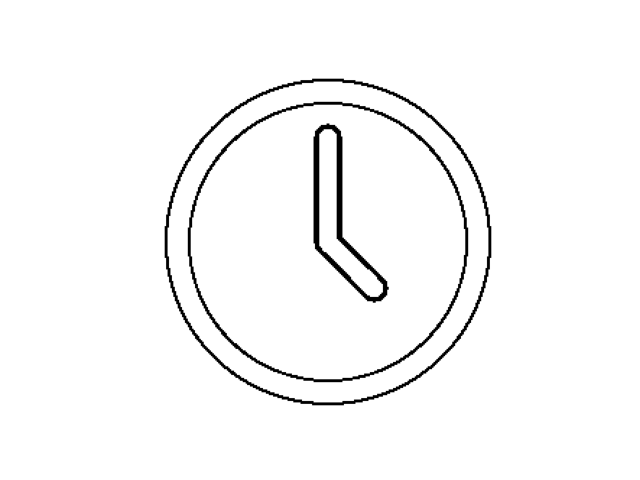
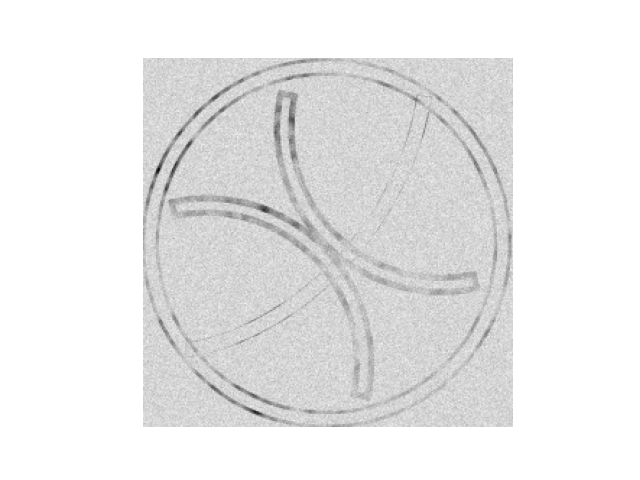
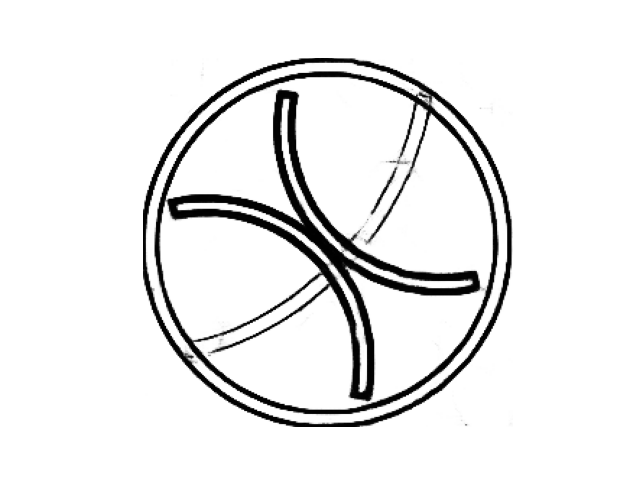
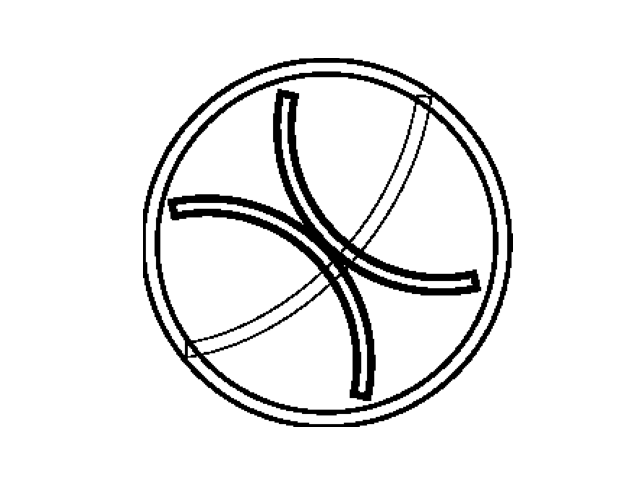
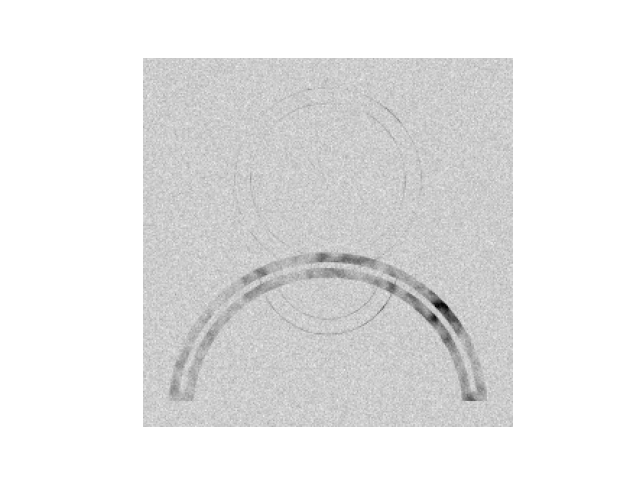
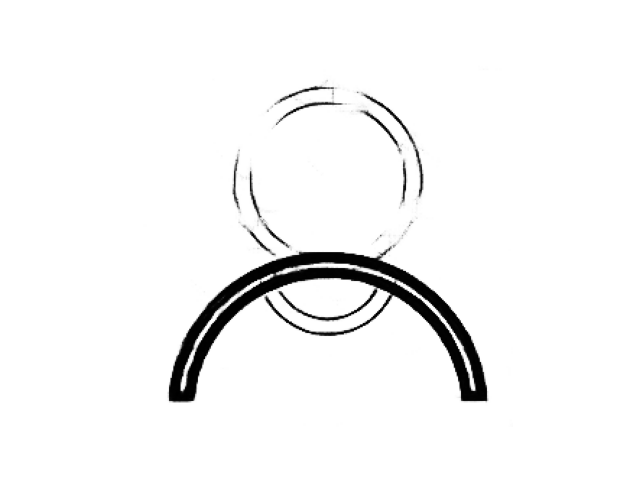
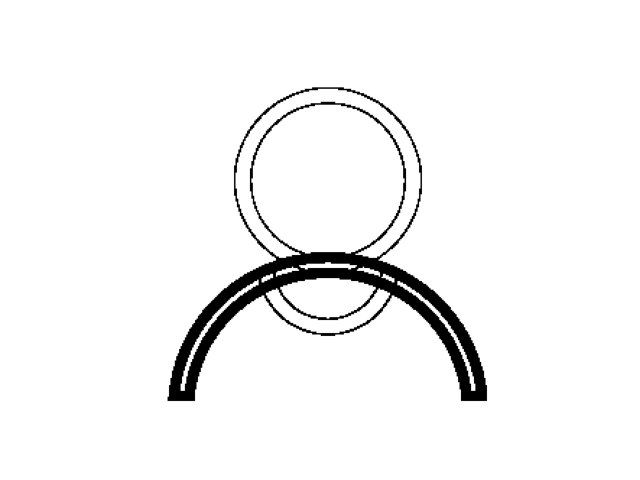

In [ ]:
_sample_x, _sample_y = next(iter(dataloader))
_sample_x = _sample_x[:6]
_sample_y = _sample_y[:6]
table(
    {
        "Input": [figure(x).text for x in _sample_x],
        "Predicted": [
            figure(p.detach()).text for p in model_cpu.forward(_sample_x)
        ],
        "Ground truth": [figure(y).text for y in _sample_y],
    }
)

On the test images (not synthetic):

Input,Predicted
,
,
,

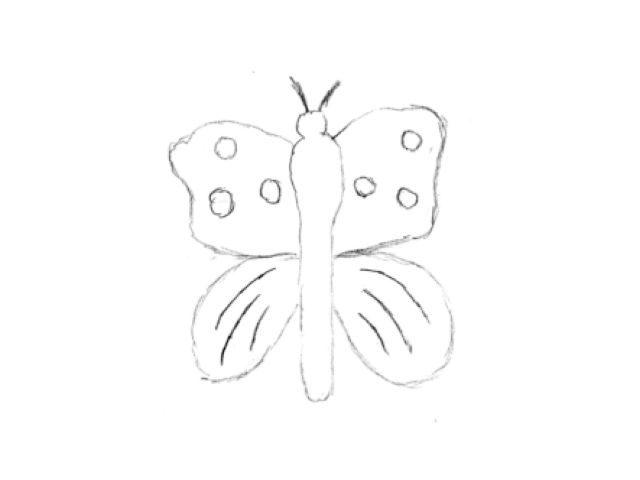
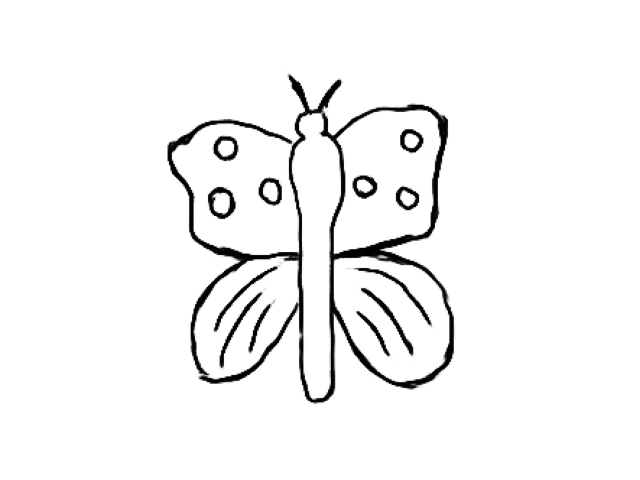
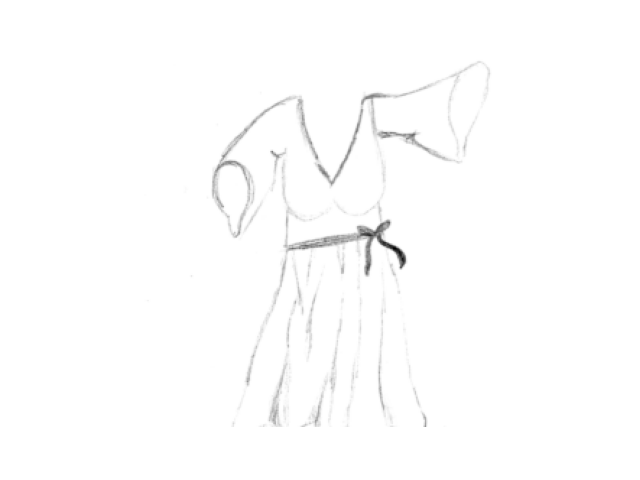
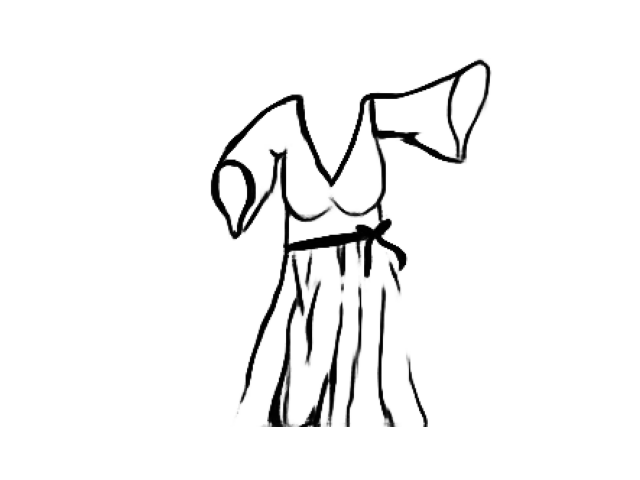
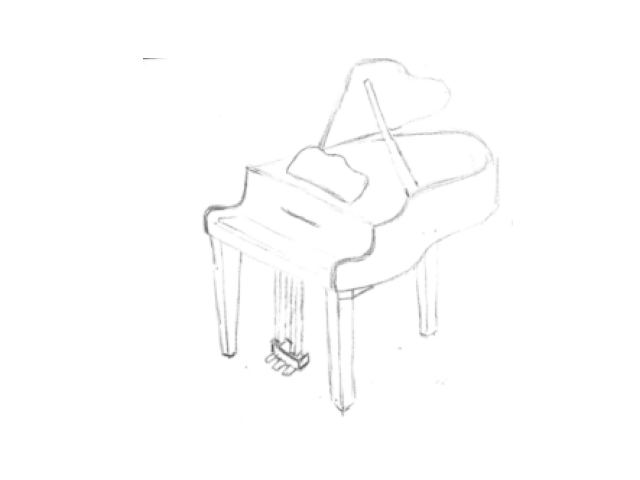
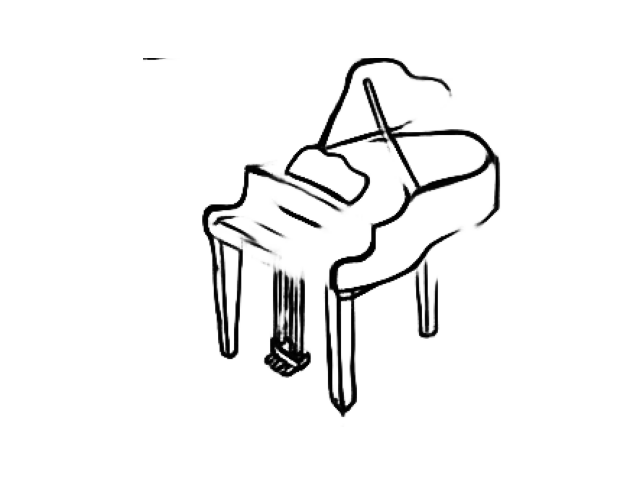

In [ ]:
_sample_x, _sample_y = next(iter(dataloader))
test_x = [
    torch.tensor(
        load_normalized(ROOT_DIR / "data" / "sketches" / f"{name}.png", d=256)
    ).unsqueeze(0)
    for name in ["butterfly", "dress", "piano"]
]
table(
    [
        {
            "Input": figure(x),
            "Predicted": figure(model_cpu.forward(x).detach()),
        }
        for x in test_x
    ]
)

# Model export

To use the model easily in the main pipeline, we convert it to [ONNX](https://onnx.ai/), a standard format for neural networks.

In [ ]:
def export_onnx(model, out_path):
    dummy_input = torch.rand((1, 256, 256), dtype=torch.float32)
    torch.onnx.export(
        model.cpu(),
        (dummy_input,),
        out_path,
        input_names=["input"],
        output_names=["output"],
        export_params=True,
        dynamic_axes={
            "input": {1: "height", 2: "width"},  # Variable H, W
            "output": {1: "height", 2: "width"},  # Variable H, W
        },
        dynamo=True
    )

In [ ]:
export_onnx(model_cpu, ROOT_DIR / "src" / "bez" / "cnn" / "model.onnx")

W0214 15:32:08.550000 65403 /system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0214 15:32:08.551000 65403 /system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0214 15:32:08.552000 65403 /system/conda/miniconda3/envs/cloudspace/lib/python3.12/site-packages/torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0214 15:32:08.553000 65403

[torch.onnx] Obtain model graph for `SketchDenoiser([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `SketchDenoiser([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 1 of general pattern rewrite rules.
